In [1]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# FIFA WORLD CUP 2026
# TASK 1: FORWARDS VS MIDFIELDERS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Display all columns instead of hiding some 
pd.set_option('display.max_columns', None)

# Formats decimal numbers to three decimal places
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Reproducibility
RANDOM_STATE = 42

# Significance level
ALPHA = 0.05

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Read CSV file using pandas
players = pd.read_csv("players.csv")

print("Dataset loaded successfully !!")

# Number of Rows and Columns
print("Rows:", players.shape[0])
print("Columns:", players.shape[1])

Dataset loaded successfully !!
Rows: 1248
Columns: 72


In [6]:
# Display the first five row of the dataset
players.head() 

,player,team,team_country,position,age,birth_year,club,games,games_starts,minutes,minutes_90s,goals,assists,goals_assists,goals_pens,pens_made,pens_att,cards_yellow,cards_red,goals_per90,assists_per90,goals_assists_per90,goals_pens_per90,goals_assists_pens_per90,shots,shots_on_target,shots_on_target_pct,shots_per90,shots_on_target_per90,goals_per_shot,goals_per_shot_on_target,minutes_per_game,minutes_pct,minutes_per_start,games_complete,games_subs,minutes_per_sub,unused_subs,points_per_game,on_goals_for,on_goals_against,plus_minus,plus_minus_per90,plus_minus_wowy,cards_yellow_red,fouls,fouled,offsides,crosses,interceptions,tackles_won,pens_won,pens_conceded,own_goals,gk_games,gk_games_starts,gk_minutes,gk_goals_against,gk_goals_against_per90,gk_shots_on_target_against,gk_saves,gk_save_pct,gk_wins,gk_ties,gk_losses,gk_clean_sheets,gk_clean_sheets_pct,gk_pens_att,gk_pens_allowed,gk_pens_saved,gk_pens_missed,gk_pens_save_pct
0,Achref Abada,Algeria,Algeria,DF,26,1999,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Adil Boulbina,Algeria,Algeria,FW,23,2003,NaN,2,0,19.000,0.200,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,NaN,NaN,10.000,5.300,NaN,0,2,10.000,2,0.000,0.000,0.000,0.000,0.000,1.060,0.000,0.000,0.000,1.000,0.000,0.000,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Amine Gouiri,Algeria,Algeria,FW,26,2000,Marseille,4,3,251.000,2.800,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.360,0.000,0.360,0.360,0.360,3.000,2.000,66.700,1.080,0.720,0.330,0.500,63.000,69.700,73.000,0,1,33.000,0,1.000,4.000,5.000,-1.000,-0.360,2.120,0.000,1.000,1.000,0.000,1.000,0.000,1.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Anis Hadj Moussa,Algeria,Algeria,MF,24,2002,Feyenoord,3,1,98.000,1.100,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,1.840,0.000,0.000,NaN,33.000,27.200,63.000,0,2,18.000,1,1.000,1.000,2.000,-1.000,-0.920,0.110,0.000,0.000,2.000,0.000,5.000,1.000,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Aïssa Mandi,Algeria,Algeria,DF,34,1991,Lille,4,4,360.000,4.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,NaN,NaN,90.000,100.000,90.000,4,0,NaN,0,1.000,5.000,9.000,-4.000,-1.000,NaN,0.000,0.000,5.000,0.000,0.000,4.000,3.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Structural information about the dataset
players.info()

<class 'pandas.DataFrame'>
RangeIndex: 1248 entries, 0 to 1247
Data columns (total 72 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   player                      1248 non-null   str    
 1   team                        1248 non-null   str    
 2   team_country                1248 non-null   str    
 3   position                    1248 non-null   str    
 4   age                         1248 non-null   int64  
 5   birth_year                  1248 non-null   int64  
 6   club                        907 non-null    str    
 7   games                       1248 non-null   int64  
 8   games_starts                1248 non-null   int64  
 9   minutes                     1039 non-null   float64
 10  minutes_90s                 1039 non-null   float64
 11  goals                       1039 non-null   float64
 12  assists                     1039 non-null   float64
 13  goals_assists               1039 non-null   

In [8]:
# Examine player positions
# Select the position column ,  counts how many times each position occurs
players['position'].value_counts(dropna=False)

# dropna = False means that the missing position values would also be included in our count

position
MF       378
DF       364
FW       169
GK       145
FW,MF     90
DF,MF     49
MF,FW     36
MF,DF     12
DF,FW      5
Name: count, dtype: int64

In [9]:
# Check missing Values 
# Here only the relevant variables are selected

players[
    ['player', 'position', 'games', 'minutes',
     'goals', 'assists', 'goals_assists_per90']
].isnull().sum()

player                   0
position                 0
games                    0
minutes                209
goals                  209
assists                209
goals_assists_per90    209
dtype: int64

In [10]:
# Creating analytical dataset
# Defining our relevant population

analysis_data = players[
    [
        'player',
        'team',
        'position',
        'games',
        'minutes',
        'minutes_90s',
        'goals',
        'assists',
        'goals_assists_per90'
    ]
    
].copy()

In [11]:
# Select FW and MF
# Defenders and goalkeepers are removed
# Combined positions are removed

analysis_data = analysis_data[
    analysis_data['position'].isin(['FW', 'MF'])
]

In [12]:

# Keep players who played at least 90 minutes
analysis_data = analysis_data[
    analysis_data['minutes'] >= 90
]

# Remove observations with missing goal contribution rate
analysis_data = analysis_data.dropna(
    subset=['goals_assists_per90']
)

# Reset the index
analysis_data = analysis_data.reset_index(drop=True)

print("Eligible Players / Population:", len(analysis_data))
print(" Players by position:")

# Count how many players belong to each group
print(analysis_data['position'].value_counts())

Eligible Players / Population: 346
 Players by position:
position
MF    250
FW     96
Name: count, dtype: int64


In [13]:
# Quality - control step
analysis_data[
    ['player', 'position', 'games', 'minutes',
     'goals', 'assists', 'goals_assists_per90']
].head(10)

,player,position,games,minutes,goals,assists,goals_assists_per90
0,Amine Gouiri,FW,4,251.000,1.000,0.000,0.360
1,Anis Hadj Moussa,MF,3,98.000,0.000,0.000,0.000
2,Fares Chaïbi,MF,4,360.000,0.000,0.000,0.000
3,Hicham Boudaoui,MF,3,128.000,0.000,0.000,0.000
4,Houssem Aouar,MF,3,173.000,0.000,2.000,1.040
5,Nabil Bentaleb,MF,4,285.000,0.000,0.000,0.000
6,Ramiz Zerrouki,MF,3,111.000,0.000,0.000,0.000
7,Riyad Mahrez,MF,4,262.000,2.000,1.000,1.030
8,Alexis Mac Allister,MF,8,750.000,1.000,1.000,0.240
9,Enzo Fernández,MF,7,659.000,2.000,0.000,0.270


In [14]:
# Checking missing values again to confirm our data cleaning actually worked 
analysis_data[
    ['player', 'position', 'games',
     'minutes', 'goals', 'assists',
     'goals_assists_per90']
].isnull().sum()

player                 0
position               0
games                  0
minutes                0
goals                  0
assists                0
goals_assists_per90    0
dtype: int64

In [15]:
# Population descriptive statistics
population_summary = (
    analysis_data
    .groupby('position')['goals_assists_per90']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        minimum='min',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        maximum='max'
    )
)

population_summary['IQR'] = (
    population_summary['Q3']
    - population_summary['Q1']
)

population_summary

,n,mean,median,std,minimum,Q1,Q3,maximum,IQR
position,,,,,,,,,
FW,96,0.480,0.275,0.594,0.000,0.000,0.840,2.980,0.840
MF,250,0.239,0.000,0.337,0.000,0.000,0.390,1.510,0.390


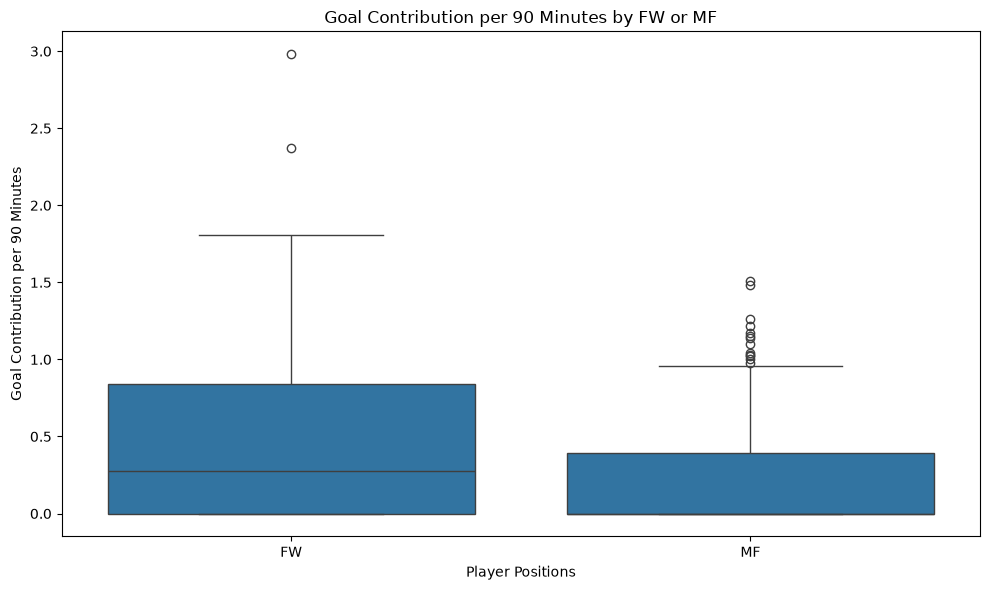

In [16]:
# Population boxplot

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=analysis_data,
    x='position',
    y='goals_assists_per90'
)
plt.title(
    'Goal Contribution per 90 Minutes by FW or MF'
)
plt.xlabel('Player Positions')

plt.ylabel(
    'Goal Contribution per 90 Minutes'
)

plt.tight_layout()

plt.show()


In [17]:
# The box plot provides an initial visual comparison of the two groups.
# The forward box are positioned higher than those of midfielders, this suggests that forwards generally
# have higher goal contribution per 90 min.


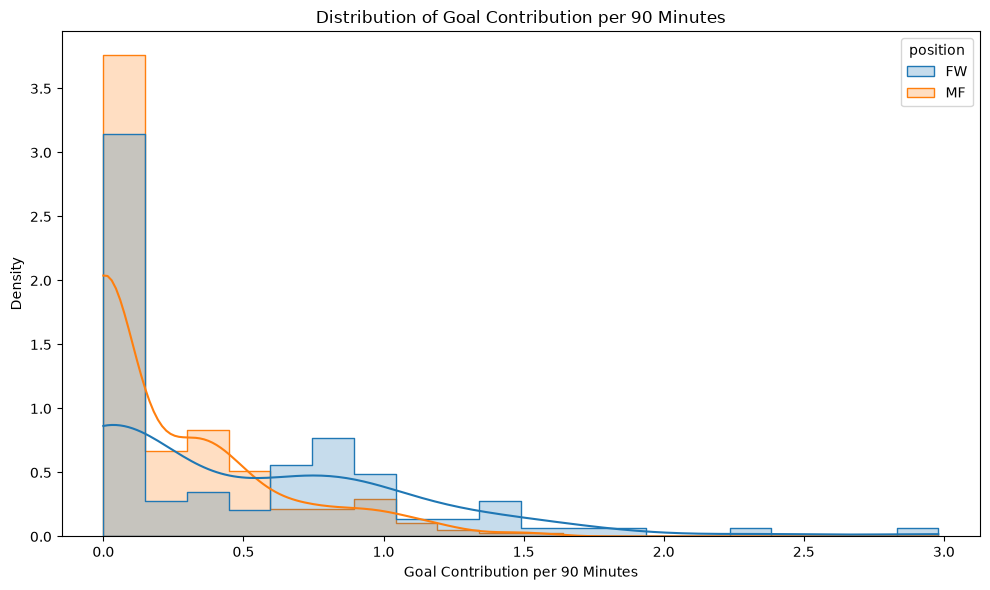

In [18]:
# Compare the distributions of goal contribution per 90

plt.figure(figsize=(10, 6))

sns.histplot(
    data=analysis_data,
    x='goals_assists_per90',
    hue='position',
    bins=20,
    kde=True,
    element='step',
    stat='density',
    common_norm=False
)

plt.title(
    'Distribution of Goal Contribution per 90 Minutes'
)

plt.xlabel(
    'Goal Contribution per 90 Minutes'
)

plt.ylabel('Density')

plt.tight_layout()

plt.show()

In [19]:
#This code creates a distribution plot to compare how goal contributions per 90 minutes are spread across different player positions. 
#It helps us see whether forwards and midfielders have different scoring/assisting patterns, including their typical values, spread, and overlap. 
#The histogram shows where most players fall, 
#while the KDE curve makes the overall shape easier to see.

In [20]:
# Define the number of players to sample from each group
SAMPLE_SIZE_PER_GROUP = 80

print(
    "Sample size per group:",
    SAMPLE_SIZE_PER_GROUP
)

Sample size per group: 80


In [21]:
# Select 80 FW and 80 MF randomly

# Create a new DataFrame named sample
# Sampling from our cleaned eligible population
sample = (
    analysis_data
    .groupby('position', group_keys=False) # prevents pandas from adding groupname into DF index
    .sample(
        n=SAMPLE_SIZE_PER_GROUP,
        random_state=RANDOM_STATE
    )
    .reset_index(drop=True)
)

print("Total sample size:", len(sample))

print("Sample size by position:")
print(sample['position'].value_counts())

Total sample size: 160
Sample size by position:
position
FW    80
MF    80
Name: count, dtype: int64


In [22]:
# Check for duplicate players
duplicate_players = sample['player'].duplicated().sum()

print("Duplicate players:", duplicate_players)

# Check missing values
print("\nMissing values:")
print(
    sample[
        [
            'player',
            'position',
            'minutes',
            'goals_assists_per90'
        ]
    ].isnull().sum()
)

Duplicate players: 0

Missing values:
player                 0
position               0
minutes                0
goals_assists_per90    0
dtype: int64


In [23]:
# Calculate descriptive statistics for the sample

sample_summary = (
    sample
    .groupby('position')['goals_assists_per90']
    .agg(
        n='count',
        mean='mean',
        median='median',
        std='std',
        minimum='min',
        Q1=lambda x: x.quantile(0.25),
        Q3=lambda x: x.quantile(0.75),
        maximum='max'
    )
)

# Calculate IQR
sample_summary['IQR'] = (
    sample_summary['Q3']
    - sample_summary['Q1']
)

sample_summary

,n,mean,median,std,minimum,Q1,Q3,maximum,IQR
position,,,,,,,,,
FW,80,0.486,0.265,0.615,0.000,0.000,0.855,2.980,0.855
MF,80,0.240,0.000,0.334,0.000,0.000,0.362,1.480,0.362


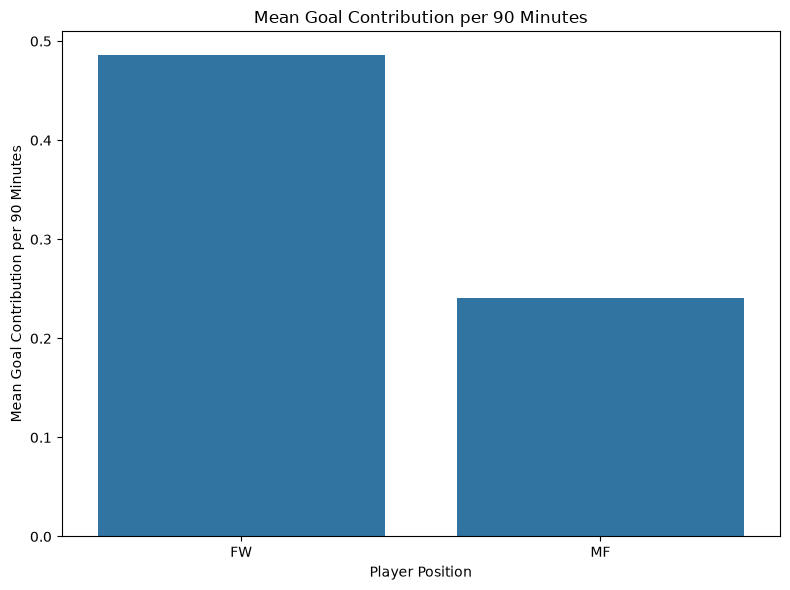

In [24]:
# Calculate mean goal contribution for each position

mean_values = (
    sample
    .groupby('position')['goals_assists_per90']
    .mean()
    .reset_index()
)

# Create bar chart
plt.figure(figsize=(8, 6))

sns.barplot(
    data=mean_values,
    x='position',
    y='goals_assists_per90'
)

# Title of the chart
plt.title(
    'Mean Goal Contribution per 90 Minutes'
)

# Labels the X-axis
plt.xlabel('Player Position')

# labels the Y-axis
plt.ylabel(
    'Mean Goal Contribution per 90 Minutes'
)

# Improves spacing
plt.tight_layout()

# Display chart
plt.show()

In [39]:
""" The bar chart here provides a direct comparison of the sample means
If the forward bar is higher than the midfielder bar 
this indicates a higher observed mean goal contribution for forward
"""

' The bar chart here provides a direct comparison of the sample means\nIf the forward bar is higher than the midfielder bar \nthis indicates a higher observed mean goal contribution for forward\n'

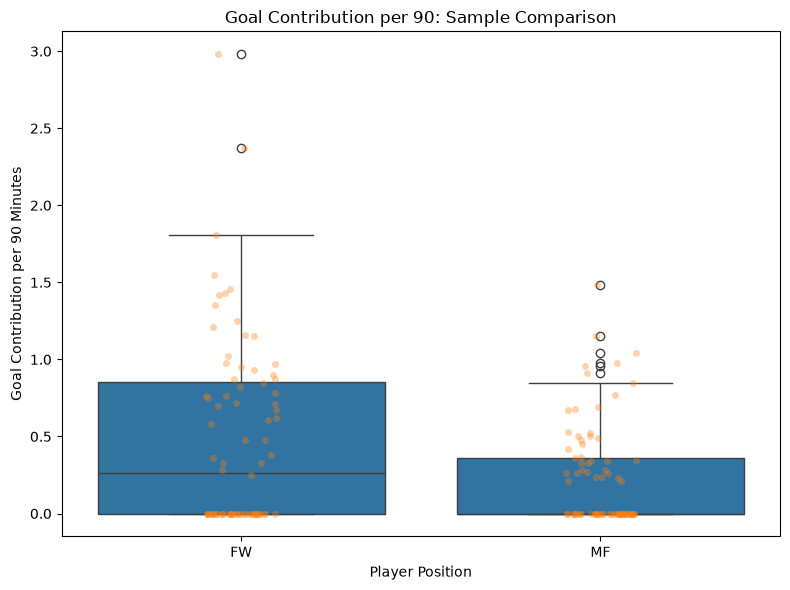

In [26]:
# Compare individual observations and distributions

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=sample,
    x='position',
    y='goals_assists_per90'
)

sns.stripplot(
    data=sample,
    x='position',
    y='goals_assists_per90',
    alpha=0.35
)

plt.title(
    'Goal Contribution per 90: Sample Comparison'
)

plt.xlabel('Player Position')

plt.ylabel(
    'Goal Contribution per 90 Minutes'
)

plt.tight_layout()

plt.show()

In [27]:
# Extract forward observations
forwards = sample.loc[
    sample['position'] == 'FW',
    'goals_assists_per90'
]

# Extract midfielder observations
midfielders = sample.loc[
    sample['position'] == 'MF',
    'goals_assists_per90'
]

print("Forward observations:", len(forwards))
print("Midfielder observations:", len(midfielders))

Forward observations: 80
Midfielder observations: 80


In [28]:
# Calculate the mean goal contribution per 90 for each position group

mean_fw = forwards.mean()
mean_mf = midfielders.mean()

print(f"Forward mean: {mean_fw:.3f}")
print(f"Midfielder mean: {mean_mf:.3f}")

Forward mean: 0.486
Midfielder mean: 0.240


In [29]:
# Calculate sample standard deviations

#calculate forward and midfielders sample standard deviation
std_fw = forwards.std(ddof=1)
std_mf = midfielders.std(ddof=1)

print(f"Forward standard deviation: {std_fw:.3f}")
print(f"Midfielder standard deviation: {std_mf:.3f}")

Forward standard deviation: 0.615
Midfielder standard deviation: 0.334


In [30]:
# Function to calculate a 95% confidence interval
# for a population mean using the t-distribution

def mean_confidence_interval(data, confidence=0.95):

    # Sample size
    n = len(data)

    # Sample mean
    mean = np.mean(data)

    # Sample standard deviation
    std = np.std(data, ddof=1)

    # Standard error
    standard_error = std / np.sqrt(n) #standard error tells how precisely the sample mean estimate popuation mean

    # Critical t-value
    critical_value = stats.t.ppf(
        (1 + confidence) / 2,
        df=n - 1
    )

    # Margin of error
    margin_of_error = (
        critical_value * standard_error
    )

    # Lower confidence limit
    lower = mean - margin_of_error

    # Upper confidence limit
    upper = mean + margin_of_error

    return mean, lower, upper

In [31]:
# Calculate the 95% CI for forwards

fw_mean, fw_lower, fw_upper = (
    mean_confidence_interval(forwards)
)

# Calculate the 95% CI for midfielders

mf_mean, mf_lower, mf_upper = (
    mean_confidence_interval(midfielders)
)

print("FORWARDS")
print(f"Mean = {mean_fw:.3f}")
print(
    f"95% CI = ({fw_lower:.3f}, "
    f"{fw_upper:.3f})"
)

print("\nMIDFIELDERS")
print(f"Mean = {mean_mf:.3f}")
print(
    f"95% CI = ({mf_lower:.3f}, "
    f"{mf_upper:.3f})"
)

FORWARDS
Mean = 0.486
95% CI = (0.349, 0.623)

MIDFIELDERS
Mean = 0.240
95% CI = (0.166, 0.315)


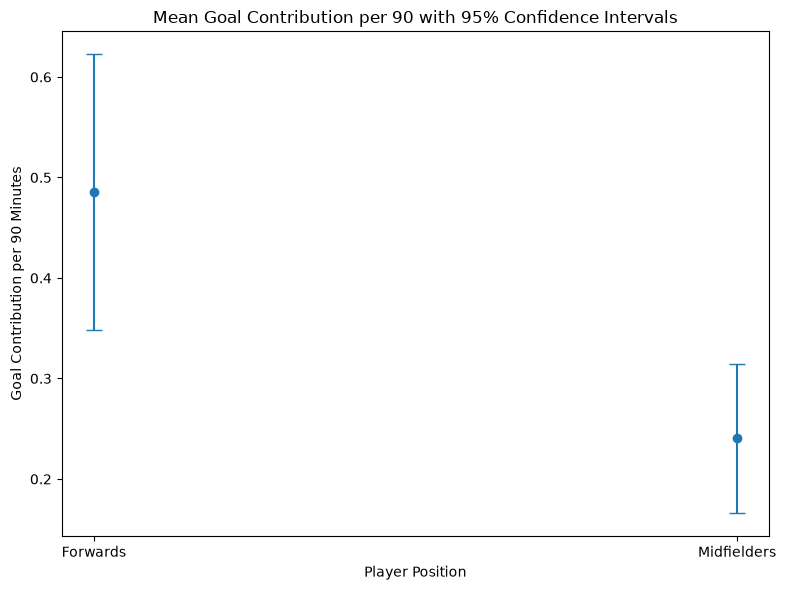

In [32]:
# Create a table containing means and confidence intervals

ci_data = pd.DataFrame({
    'Position': [
        'Forwards',
        'Midfielders'
    ],
    'Mean': [
        mean_fw,
        mean_mf
    ],
    'Lower': [
        fw_lower,
        mf_lower
    ],
    'Upper': [
        fw_upper,
        mf_upper
    ]
})

# Plot means with 95% confidence intervals

plt.figure(figsize=(8, 6))

plt.errorbar(
    ci_data['Position'],
    ci_data['Mean'],
    yerr=[
        ci_data['Mean'] - ci_data['Lower'],
        ci_data['Upper'] - ci_data['Mean']
    ],
    fmt='o',
    capsize=6
)

plt.title(
    'Mean Goal Contribution per 90 with 95% Confidence Intervals'
)

plt.xlabel('Player Position')

plt.ylabel(
    'Goal Contribution per 90 Minutes'
)

plt.tight_layout()

plt.show()

In [33]:
# Shapiro-Wilk normality test for forwards
fw_shapiro = stats.shapiro(forwards)

# Shapiro-Wilk normality test for midfielders
mf_shapiro = stats.shapiro(midfielders)

print("FORWARDS")
print(
    f"Statistic = {fw_shapiro.statistic:.3f}"
)
print(
    f"p-value = {fw_shapiro.pvalue:.6f}"
)

print("\nMIDFIELDERS")
print(
    f"Statistic = {mf_shapiro.statistic:.3f}"
)
print(
    f"p-value = {mf_shapiro.pvalue:.6f}"
)

FORWARDS
Statistic = 0.788
p-value = 0.000000

MIDFIELDERS
Statistic = 0.754
p-value = 0.000000


In [34]:
#The Shapiro-Wilk test produced p-values below 0.05 for both forwards and midfielders.
#Therefore, we rejected the assumption of normality, indicating that goal contribution per 90 minutes is not normally distributed in either group

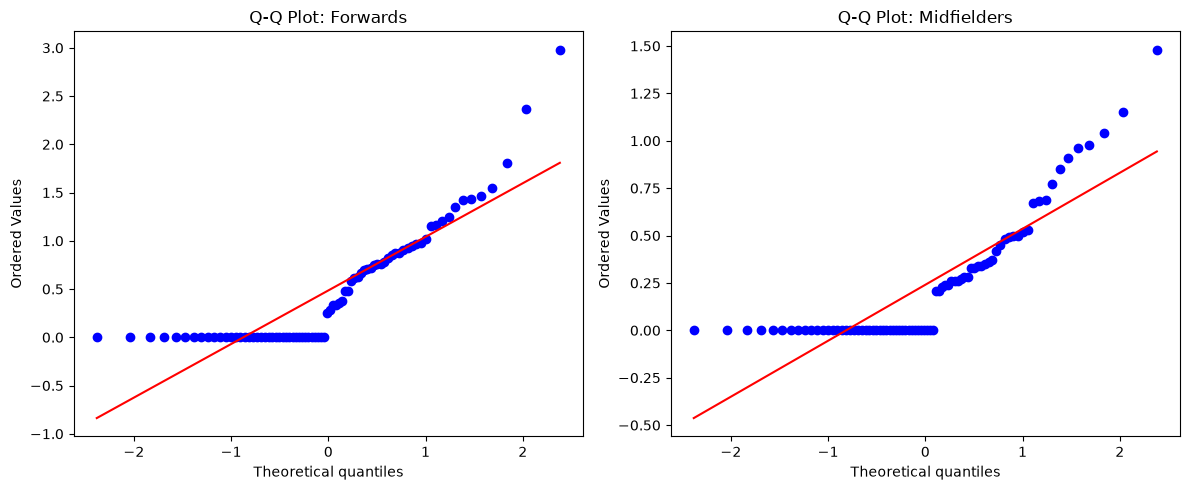

In [35]:
# Create Q-Q plots to visually assess normality

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

# Forward Q-Q plot
stats.probplot(
    forwards,
    dist="norm",
    plot=axes[0]
)

axes[0].set_title(
    'Q-Q Plot: Forwards'
)

# Midfielder Q-Q plot
stats.probplot(
    midfielders,
    dist="norm",
    plot=axes[1]
)

axes[1].set_title(
    'Q-Q Plot: Midfielders'
)

plt.tight_layout()

plt.show()

In [36]:
# Levene's test checks whether the two groups
# have equal variances

levene_test = stats.levene(
    forwards,
    midfielders,
    center='median'
)

print("Levene's Test")
print(
    f"Statistic = {levene_test.statistic:.3f}"
)
print(
    f"p-value = {levene_test.pvalue:.6f}"
)

Levene's Test
Statistic = 14.891
p-value = 0.000166


In [38]:
"""
Here We used the Shapiro-Wilk test and Q-Q plot to check whether the data were normally distributed. 
Both checks suggested that the data were not perfectly normal.
We then used Levene’s test to check whether the forwards and midfielders had similar levels of variation. 
The result was significant (p = 0.000166), meaning the two groups had different variances. 
Based on these results, we chose Welch’s t-test, as it is better suited for comparing two groups when their variances are unequal.
"""


'\nHere We used the Shapiro-Wilk test and Q-Q plot to check whether the data were normally distributed. \nBoth checks suggested that the data were not perfectly normal.\nWe then used Levene’s test to check whether the forwards and midfielders had similar levels of variation. \nThe result was significant (p = 0.000166), meaning the two groups had different variances. \nBased on these results, we chose Welch’s t-test, as it is better suited for comparing two groups when their variances are unequal.\n'

In [37]:
# main hypothesis

# Welch's independent two-sample t-test
# alternative='greater' tests whether:
# mean(forwards) > mean(midfielders)

t_test = stats.ttest_ind(
    forwards,
    midfielders,
    equal_var=False,
    alternative='greater'
)

print("Welch's Independent Two-Sample t-Test")

print(
    f"t-statistic = {t_test.statistic:.3f}"
)
print(
    f"p-value = {t_test.pvalue:.6f}"
)

Welch's Independent Two-Sample t-Test
t-statistic = 3.133
p-value = 0.001085


In [40]:
# Sample sizes
n_fw = len(forwards)
n_mf = len(midfielders)

# Sample variances
var_fw = forwards.var(ddof=1)
var_mf = midfielders.var(ddof=1)

# Welch-Satterthwaite degrees of freedom

welch_df = (
    ((var_fw / n_fw) + (var_mf / n_mf)) ** 2
    /
    (
        ((var_fw / n_fw) ** 2 / (n_fw - 1))
        +
        ((var_mf / n_mf) ** 2 / (n_mf - 1))
    )
)

print(
    f"Welch degrees of freedom = {welch_df:.2f}"
)

Welch degrees of freedom = 121.82


In [41]:
# Calculate the difference between the two sample means

mean_difference = (
    fw_mean - mf_mean
)

print(
    f"Forward mean - Midfielder mean = "
    f"{mean_difference:.3f}"
)

Forward mean - Midfielder mean = 0.245


In [42]:
# Calculate the standard error of the difference

standard_error_difference = np.sqrt(
    (var_fw / n_fw) +
    (var_mf / n_mf)
)

# Critical t-value for 95% CI

critical_value = stats.t.ppf(
    0.975,
    df=welch_df
)

# Calculate confidence interval

difference_lower = (
    mean_difference
    - critical_value * standard_error_difference
)

difference_upper = (
    mean_difference
    + critical_value * standard_error_difference
)

print(
    f"Mean difference = {mean_difference:.3f}"
)

print(
    f"95% CI for difference = "
    f"({difference_lower:.3f}, "
    f"{difference_upper:.3f})"
)

Mean difference = 0.245
95% CI for difference = (0.090, 0.400)


In [49]:
# Calculate pooled standard deviation

pooled_sd = np.sqrt(
    (
        (n_fw - 1) * var_fw
        +
        (n_mf - 1) * var_mf
    )
    /
    (n_fw + n_mf - 2)
)

# Calculate Cohen's d

cohens_d = (
    mean_difference / pooled_sd
)

print(
    f"Cohen's d = {cohens_d:.3f}"
)
# Interpret the magnitude of Cohen's d

abs_d = abs(cohens_d)

if abs_d < 0.2:
    effect_interpretation = "negligible"
elif abs_d < 0.5:
    effect_interpretation = "small"
elif abs_d < 0.8:
    effect_interpretation = "medium"
else:
    effect_interpretation = "large"

print(
    f"Effect size interpretation: "
    f"{effect_interpretation}"
)

Cohen's d = 0.495
Effect size interpretation: small


In [44]:
"""
The point of calculating Cohen's d is 
to find out how large or meaningful the difference between forwards and midfielders is.
The Welch t-test tells us whether the difference is statistically significant,
but Cohen's d tells us the size of that difference relative to the overall variation in the data

"""

"\nThe point of calculating Cohen's d is \nto find out how large or meaningful the difference between forwards and midfielders is.\nThe Welch t-test tells us whether the difference is statistically significant,\nbut Cohen's d tells us the size of that difference relative to the overall variation in the data\n\n"

In [45]:
# ============================================================
# BOOTSTRAP SENSITIVITY ANALYSIS
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)

# Number of bootstrap repetitions
B = 10000

# Store bootstrap differences
bootstrap_differences = np.empty(B)

# Convert Series to NumPy arrays
fw_values = forwards.to_numpy()
mf_values = midfielders.to_numpy()

# Perform bootstrap resampling

for i in range(B):

    # Resample forwards with replacement
    fw_bootstrap = rng.choice(
        fw_values,
        size=len(fw_values),
        replace=True
    )

    # Resample midfielders with replacement
    mf_bootstrap = rng.choice(
        mf_values,
        size=len(mf_values),
        replace=True
    )

    # Difference between bootstrap means
    bootstrap_differences[i] = (
        fw_bootstrap.mean()
        - mf_bootstrap.mean()
    )

# Calculate bootstrap 95% confidence interval

bootstrap_ci = np.percentile(
    bootstrap_differences,
    [2.5, 97.5]
)

print(
    f"Bootstrap 95% CI = "
    f"({bootstrap_ci[0]:.3f}, "
    f"{bootstrap_ci[1]:.3f})"
)

Bootstrap 95% CI = (0.095, 0.399)


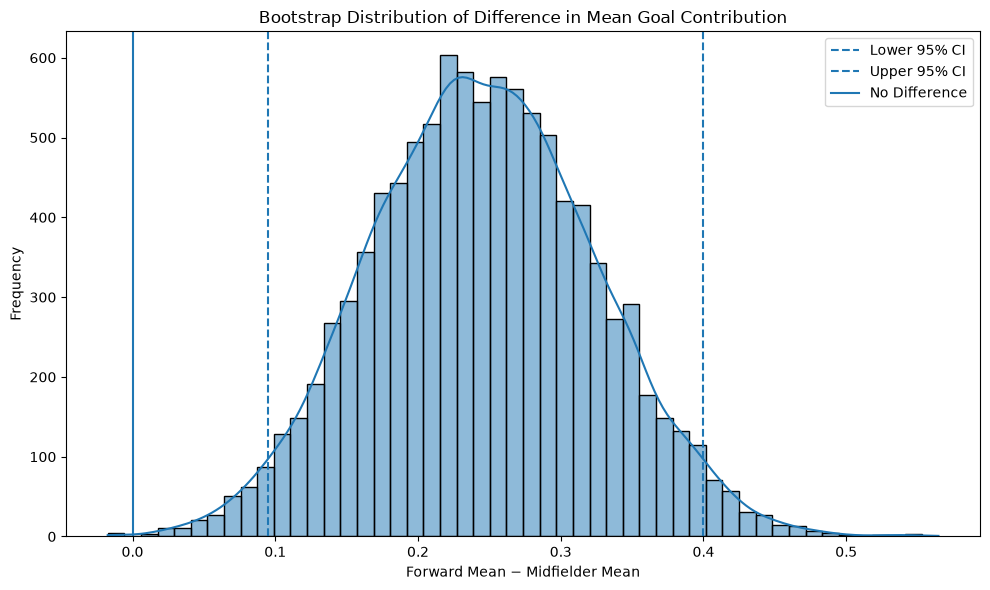

In [46]:
# Plot bootstrap distribution of mean differences

plt.figure(figsize=(10, 6))

sns.histplot(
    bootstrap_differences,
    bins=50,
    kde=True
)

# Lower CI
plt.axvline(
    bootstrap_ci[0],
    linestyle='--',
    label='Lower 95% CI'
)

# Upper CI
plt.axvline(
    bootstrap_ci[1],
    linestyle='--',
    label='Upper 95% CI'
)

# Zero represents no difference
plt.axvline(
    0,
    linestyle='-',
    label='No Difference'
)

plt.title(
    'Bootstrap Distribution of Difference in Mean Goal Contribution'
)

plt.xlabel(
    'Forward Mean − Midfielder Mean'
)

plt.ylabel('Frequency')

plt.legend()

plt.tight_layout()

plt.show()

Cohen's d = 0.495
Effect size interpretation: small


In [50]:
# ============================================================
# FINAL STATISTICAL DECISION
# ============================================================

print("=" * 60)
print("FINAL STATISTICAL ANALYSIS")
print("=" * 60)

print(
    f"Forward sample size: {n_fw}"
)

print(
    f"Midfielder sample size: {n_mf}"
)

print(
    f"Forward mean: {fw_mean:.3f}"
)

print(
    f"Midfielder mean: {mf_mean:.3f}"
)

print(
    f"Mean difference: {mean_difference:.3f}"
)

print(
    f"Forward 95% CI: "
    f"({fw_lower:.3f}, {fw_upper:.3f})"
)

print(
    f"Midfielder 95% CI: "
    f"({mf_lower:.3f}, {mf_upper:.3f})"
)

print(
    f"Difference 95% CI: "
    f"({difference_lower:.3f}, "
    f"{difference_upper:.3f})"
)

print(
    f"Welch t-statistic: "
    f"{t_test.statistic:.3f}"
)

print(
    f"Welch degrees of freedom: "
    f"{welch_df:.2f}"
)

print(
    f"One-tailed p-value: "
    f"{t_test.pvalue:.6f}"
)

print(
    f"Cohen's d: {cohens_d:.3f}"
)

print(
    f"Bootstrap 95% CI: "
    f"({bootstrap_ci[0]:.3f}, "
    f"{bootstrap_ci[1]:.3f})"
)

print("\nSignificance level:", ALPHA)

print("\nDECISION:")

if t_test.pvalue < ALPHA:

    print("Reject H0.")

    print(
        "There is statistically significant evidence "
        "that forwards have a higher mean goal "
        "contribution per 90 minutes than midfielders."
    )

else:

    print("Fail to reject H0.")

    print(
        "There is insufficient statistical evidence "
        "to conclude that forwards have a higher mean "
        "goal contribution per 90 minutes than midfielders."
    )

FINAL STATISTICAL ANALYSIS
Forward sample size: 80
Midfielder sample size: 80
Forward mean: 0.486
Midfielder mean: 0.240
Mean difference: 0.245
Forward 95% CI: (0.349, 0.623)
Midfielder 95% CI: (0.166, 0.315)
Difference 95% CI: (0.090, 0.400)
Welch t-statistic: 3.133
Welch degrees of freedom: 121.82
One-tailed p-value: 0.001085
Cohen's d: 0.495
Bootstrap 95% CI: (0.095, 0.399)

Significance level: 0.05

DECISION:
Reject H0.
There is statistically significant evidence that forwards have a higher mean goal contribution per 90 minutes than midfielders.


In [52]:
# Define the population size
population_size = len(analysis_data)

print("Population size:", population_size)

Population size: 346


In [53]:
# Create a concise table of the main statistical results

results_table = pd.DataFrame({
    'Statistic': [
        'Eligible population',
        'Forward population',
        'Midfielder population',
        'Forward sample',
        'Midfielder sample',
        'Forward mean',
        'Midfielder mean',
        'Mean difference',
        'Forward 95% CI',
        'Midfielder 95% CI',
        'Difference 95% CI',
        'Welch t-statistic',
        'Welch degrees of freedom',
        'One-tailed p-value',
        "Cohen's d",
        'Bootstrap 95% CI'
    ],

    'Value': [
        population_size,
        len(analysis_data[
            analysis_data['position'] == 'FW'
        ]),
        len(analysis_data[
            analysis_data['position'] == 'MF'
        ]),
        n_fw,
        n_mf,
        round(fw_mean, 3),
        round(mf_mean, 3),
        round(mean_difference, 3),
        f"({fw_lower:.3f}, {fw_upper:.3f})",
        f"({mf_lower:.3f}, {mf_upper:.3f})",
        f"({difference_lower:.3f}, {difference_upper:.3f})",
        round(t_test.statistic, 3),
        round(welch_df, 2),
        round(t_test.pvalue, 6),
        round(cohens_d, 3),
        f"({bootstrap_ci[0]:.3f}, "
        f"{bootstrap_ci[1]:.3f})"
    ]
})

results_table

,Statistic,Value
0,Eligible population,346
1,Forward population,96
2,Midfielder population,250
3,Forward sample,80
4,Midfielder sample,80
5,Forward mean,0.486
6,Midfielder mean,0.240
7,Mean difference,0.245
8,Forward 95% CI,"(0.349, 0.623)"
9,Midfielder 95% CI,"(0.166, 0.315)"
